# Simulating noisy gates and quantum error correction


In [1]:
pip install qutip

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [2]:
from quantum_algorithms import (
    I, X, Y, Z, H, P0, P1, 
    U_N_qubits, U_one_gate, U_two_gates, controlled_gate, rotation_gate,
    rho, evolve, doMeasurement, recovery_bit_flip,
    recovery_phase_flip, initial_state, apply_hadamards,
    projectors, born_rule_probs, sample_from_probs,
    measure_pure_state, measurement_density_matrix,
    measure_probs_first_n, sample_measurements_input, sample_probs,
    oracle_function, deutsch_jozsa, rotation_channel, 
    deutsch_jozsa_error1, deutsch_jozsa_error2,
    deutsch_jozsa_error3, deutsch_jozsa_error4,
    f_constant_0, f_constant_1, f_balanced_parity,
    bit_flip_kraus, phase_flip_kraus, amplitude_damping_kraus,
    phase_damping_kraus, depolarizing_kraus, pauli_kraus_channel, bit_flip_channel_3qubits, 
    apply_channel, apply_kraus, E1_rho, apply_bitflips, bloch_visualization, correct_bit_flip, syndrome_measurement, 
    dm, random_pure_state, ket0, ket1, ket_plus, bloch_vector, encode_3_qubit_bit_flip_code, ket_minus
)

Simulator by including the possibility of noisy (non-unitary) channels to real quantum computers. this framework to study common quantum channels and simulate quantum error correction protocols.

# Problem 1: Single qubit channels

We start by implementing common single-qubit channels and visualizing their action on the Bloch sphere. Compared to the purely unitary case, the state of the system is now described by a density matrix $|\psi\rangle\rightarrow \rho$, and unitary operations are replaced by general quantum channels $U\rightarrow \mathcal{E}(\rho)$. Hint: For setting up the density matrix of a pure state  $\rho = |\psi\rangle \langle \psi|$ the numpy function `np.outer(psi.conj(),psi)` might be helpful.

#### (a) Defining a channel

Generate an array of Kraus operators $M_i$ for the bit flip, phase flip and amplitude damping channel.

Write a function that takes as an input (1) a density matrix of a single qubit and (2) the list of Kraus operators defining the channels and returns the density matrix after the channel has been applied.

Test your functions by applying, e.g., the bit flip channel to the states $|0\rangle$ and $|+\rangle$.

[0.70710678+0.j 0.70710678+0.j]
[[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]


 X-axis:
 [[0.92387953+0.j         0.        -0.38268343j]
 [0.        -0.38268343j 0.92387953+0.j        ]]


Kraus operators for X-axis channel:
 [array([[0.83666003+0.j, 0.        +0.j],
       [0.        +0.j, 0.83666003+0.j]]), array([[0.50602966+0.j        , 0.        -0.20960435j],
       [0.        -0.20960435j, 0.50602966+0.j        ]])]


Density matrix after X channel:
 [[0.5-1.01719705e-18j 0.5+3.42696288e-18j]
 [0.5-1.01719705e-18j 0.5+3.42696288e-18j]]

initial Bloch vector: [1. 0. 0.]
Bloch vector after X channel: [ 1.00000000e+00 -4.44415993e-18 -5.55111512e-17]


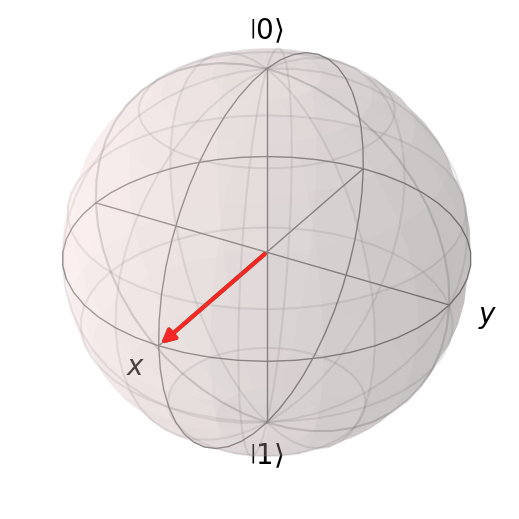

In [69]:
import numpy as np
from qutip import Bloch  

# Parameters
theta = np.pi / 4  
p = 0.3             
n = [1, 0, 0]    

# Initial state |+>
psi = ket_plus()  
rho_in = np.outer(psi, psi.conj())  

print(psi)
print(rho_in)

R_x  = rotation_gate(theta, n)
print()
print("\n X-axis:\n", R_x)

print()
kraus_x = rotation_channel(p, R_x)
rho_x = apply_kraus(rho_in, kraus_x)


# Print Kraus operators and resulting state
print("\nKraus operators for X-axis channel:\n", kraus_x)
print()
print("\nDensity matrix after X channel:\n", rho_x)
print()
# Compute Bloch vectors
v_initial = bloch_vector(rho_in)
v_x = bloch_vector(rho_x)

print("initial Bloch vector:", v_initial)
print("Bloch vector after X channel:", v_x)

# Visualize on Bloch sphere
b = Bloch()
b.vector_color = ['green', 'red']  # green = original, red = after channel
b.add_vectors(v_initial)  
b.add_vectors(v_x)        
b.title = "X-axis Random Rotation Channel Effect on |+>"
b.show()

[ 0.70710678+0.j -0.70710678+0.j]
[[ 0.5+0.j -0.5-0.j]
 [-0.5+0.j  0.5+0.j]]


 X-axis:
 [[0.92387953+0.j         0.        -0.38268343j]
 [0.        -0.38268343j 0.92387953+0.j        ]]


Kraus operators for X-axis channel:
 [array([[0.83666003+0.j, 0.        +0.j],
       [0.        +0.j, 0.83666003+0.j]]), array([[0.50602966+0.j        , 0.        -0.20960435j],
       [0.        -0.20960435j, 0.50602966+0.j        ]])]


Density matrix after X channel:
 [[ 0.5+1.01719705e-18j -0.5+3.42696288e-18j]
 [-0.5-1.01719705e-18j  0.5-3.42696288e-18j]]

initial Bloch vector: [-1.  0.  0.]
Bloch vector after X channel: [-1.00000000e+00 -4.44415993e-18 -5.55111512e-17]


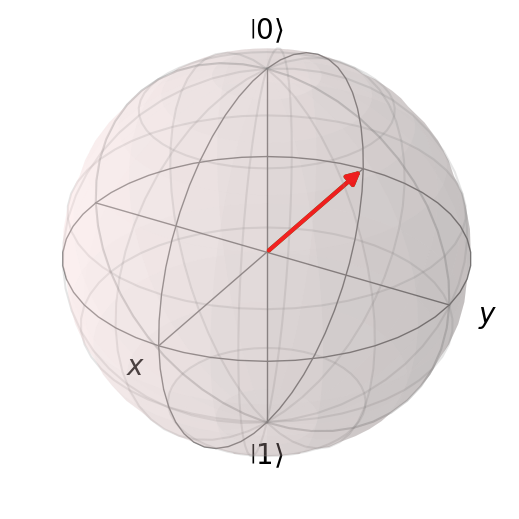

In [70]:
import numpy as np
from qutip import Bloch  

theta = np.pi / 4  
p = 0.3             
n = [1, 0, 0]    

psi = ket_minus()  
rho_in = np.outer(psi, psi.conj())  

print(psi)
print(rho_in)

R_x  = rotation_gate(theta, n)
print()
print("\n X-axis:\n", R_x)

print()
kraus_x = rotation_channel(p, R_x)
rho_x = apply_kraus(rho_in, kraus_x)


print("\nKraus operators for X-axis channel:\n", kraus_x)
print()
print("\nDensity matrix after X channel:\n", rho_x)
print()

v_initial = bloch_vector(rho_in)
v_x = bloch_vector(rho_x)

print("initial Bloch vector:", v_initial)
print("Bloch vector after X channel:", v_x)


b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_x)        
b.title = "X-axis Random Rotation Channel Effect on |->"
b.show()

[1.+0.j 0.+0.j]
\initial state:
 [1.+0.j 0.+0.j]

[[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]
\initial state:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]


 X-axis:
 [[0.92387953+0.j         0.        -0.38268343j]
 [0.        -0.38268343j 0.92387953+0.j        ]]


Kraus operators for X-axis channel:
 [array([[0.83666003+0.j, 0.        +0.j],
       [0.        +0.j, 0.83666003+0.j]]), array([[0.50602966+0.j        , 0.        -0.20960435j],
       [0.        -0.20960435j, 0.50602966+0.j        ]])]


Density matrix after X channel:
 [[0.95606602+0.j         0.        +0.10606602j]
 [0.        -0.10606602j 0.04393398+0.j        ]]

initial Bloch vector: [0. 0. 1.]
Bloch vector after X channel: [ 0.         -0.21213203  0.91213203]


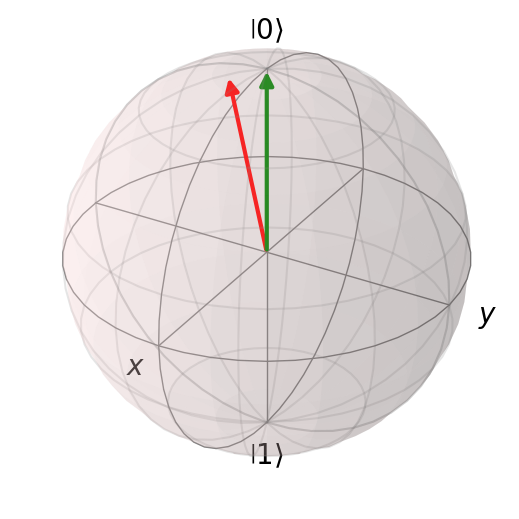

In [74]:
import numpy as np
from qutip import Bloch  

theta = np.pi / 4  
p = 0.3             
n = [1, 0, 0]    

psi = ket0()  
rho_in = np.outer(psi, psi.conj())  

print(psi)
print("\initial state:\n", psi)
print()
print(rho_in)
print("\initial state:\n", rho_in)

R_x  = rotation_gate(theta, n)
print()
print("\n X-axis:\n", R_x)

print()
kraus_x = rotation_channel(p, R_x)
rho_x = apply_kraus(rho_in, kraus_x)


print("\nKraus operators for X-axis channel:\n", kraus_x)
print()
print("\nDensity matrix after X channel:\n", rho_x)
print()

v_initial = bloch_vector(rho_in)
v_x = bloch_vector(rho_x)

print("initial Bloch vector:", v_initial)
print("Bloch vector after X channel:", v_x)


b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_x)        
b.title = "X-axis Random Rotation Channel Effect on |0>"
b.show()

[0.+0.j 1.+0.j]
[[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


 X-axis:
 [[0.92387953+0.j         0.        -0.38268343j]
 [0.        -0.38268343j 0.92387953+0.j        ]]


Kraus operators for X-axis channel:
 [array([[0.31622777+0.j, 0.        +0.j],
       [0.        +0.j, 0.31622777+0.j]]), array([[0.87646908+0.j        , 0.        -0.36304538j],
       [0.        -0.36304538j, 0.87646908+0.j        ]])]


Density matrix after X channel:
 [[0.13180195+0.j         0.        -0.31819805j]
 [0.        +0.31819805j 0.86819805+0.j        ]]

initial Bloch vector: [ 0.  0. -1.]
Bloch vector after X channel: [ 0.         0.6363961 -0.7363961]


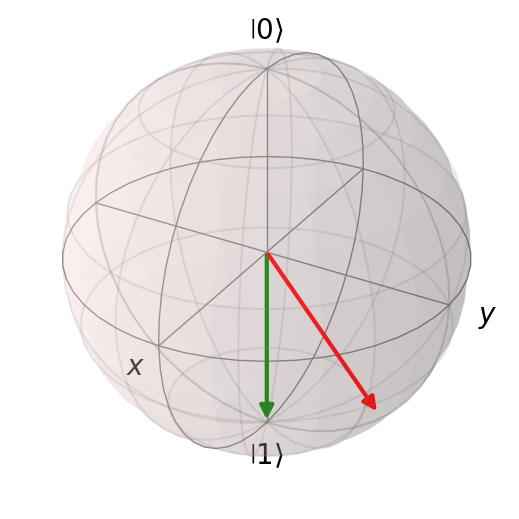

In [93]:
import numpy as np
from qutip import Bloch  

theta = np.pi / 4  
p = 0.9            
n = [1, 0, 0]    


psi = ket1()  
rho_in = np.outer(psi, psi.conj())  

print(psi)
print(rho_in)

R_x  = rotation_gate(theta, n)
print()
print("\n X-axis:\n", R_x)

print()
kraus_x = rotation_channel(p, R_x)
rho_x = apply_kraus(rho_in, kraus_x)


print("\nKraus operators for X-axis channel:\n", kraus_x)
print()
print("\nDensity matrix after X channel:\n", rho_x)
print()
# Compute Bloch vectors
v_initial = bloch_vector(rho_in)
v_x = bloch_vector(rho_x)

print("initial Bloch vector:", v_initial)
print("Bloch vector after X channel:", v_x)


b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_x)        
b.title = "X-axis Random Rotation Channel Effect on |1>"
b.show()

[1.+0.j 0.+0.j]
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]


 y-axis:
 [[ 0.92387953+0.j -0.38268343+0.j]
 [ 0.38268343+0.j  0.92387953+0.j]]


Kraus operators for y-axis channel:
 [array([[0.31622777+0.j, 0.        +0.j],
       [0.        +0.j, 0.31622777+0.j]]), array([[ 0.87646908+0.j, -0.36304538+0.j],
       [ 0.36304538+0.j,  0.87646908+0.j]])]


Density matrix after y channel:
 [[0.86819805+0.j 0.31819805+0.j]
 [0.31819805+0.j 0.13180195+0.j]]

initial Bloch vector: [0. 0. 1.]
Bloch vector after Y channel: [0.6363961 0.        0.7363961]


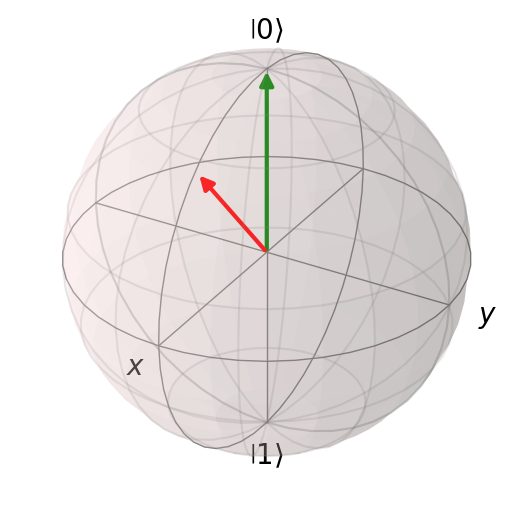

In [94]:
import numpy as np
from qutip import Bloch  

theta = np.pi / 4  
p = 0.9             
n = [0, 1, 0]    

psi = ket0()  
rho_in = np.outer(psi, psi.conj())  

print(psi)
print(rho_in)

R_y  = rotation_gate(theta, n)
print()
print("\n y-axis:\n", R_y)

print()
kraus_y = rotation_channel(p, R_y)
rho_y = apply_kraus(rho_in, kraus_y)


print("\nKraus operators for y-axis channel:\n", kraus_y)
print()
print("\nDensity matrix after y channel:\n", rho_y)
print()

v_initial = bloch_vector(rho_in)
v_y = bloch_vector(rho_y)

print("initial Bloch vector:", v_initial)
print("Bloch vector after Y channel:", v_y)

b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_y)        
b.title = "Y-axis Random Rotation Channel Effect on |1>"
b.show()

[0.+0.j 1.+0.j]
[[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


 Y-axis:
 [[ 0.92387953+0.j -0.38268343+0.j]
 [ 0.38268343+0.j  0.92387953+0.j]]


Kraus operators for y-axis channel:
 [array([[0.31622777+0.j, 0.        +0.j],
       [0.        +0.j, 0.31622777+0.j]]), array([[ 0.87646908+0.j, -0.36304538+0.j],
       [ 0.36304538+0.j,  0.87646908+0.j]])]


Density matrix after y channel:
 [[ 0.13180195+0.j -0.31819805+0.j]
 [-0.31819805+0.j  0.86819805+0.j]]

initial Bloch vector: [ 0.  0. -1.]
Bloch vector after Y channel: [-0.6363961  0.        -0.7363961]


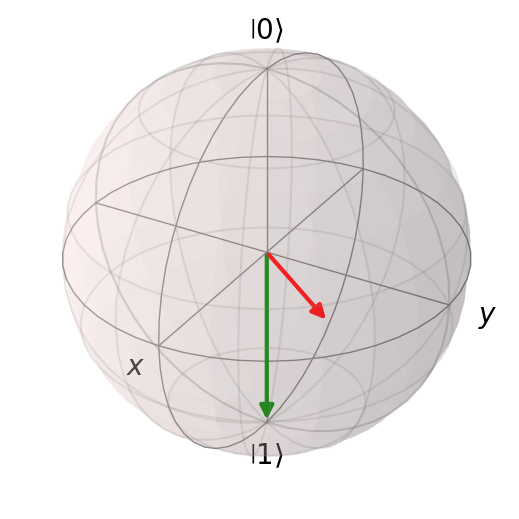

In [95]:
import numpy as np
from qutip import Bloch  


theta = np.pi / 4  
p = 0.9             
n = [0, 1, 0]    

psi = ket1()  
rho_in = np.outer(psi, psi.conj())  

print(psi)
print(rho_in)

R_y  = rotation_gate(theta, n)
print()
print("\n Y-axis:\n", R_y)

print()
kraus_y = rotation_channel(p, R_y)
rho_y = apply_kraus(rho_in, kraus_y)


print("\nKraus operators for y-axis channel:\n", kraus_y)
print()
print("\nDensity matrix after y channel:\n", rho_y)
print()

v_initial = bloch_vector(rho_in)
v_y = bloch_vector(rho_y)

print("initial Bloch vector:", v_initial)
print("Bloch vector after Y channel:", v_y)


b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_y)        
b.title = "Y-axis Random Rotation Channel Effect on |1>"
b.show()

[1.+0.j 0.+0.j]
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]


 y-axis:
 [[ 0.92387953+0.j -0.38268343+0.j]
 [ 0.38268343+0.j  0.92387953+0.j]]


Kraus operators for y-axis channel:
 [array([[0.31622777+0.j, 0.        +0.j],
       [0.        +0.j, 0.31622777+0.j]]), array([[ 0.87646908+0.j, -0.36304538+0.j],
       [ 0.36304538+0.j,  0.87646908+0.j]])]


Density matrix after y channel:
 [[0.86819805+0.j 0.31819805+0.j]
 [0.31819805+0.j 0.13180195+0.j]]

initial Bloch vector: [0. 0. 1.]
Bloch vector after Y channel: [0.6363961 0.        0.7363961]


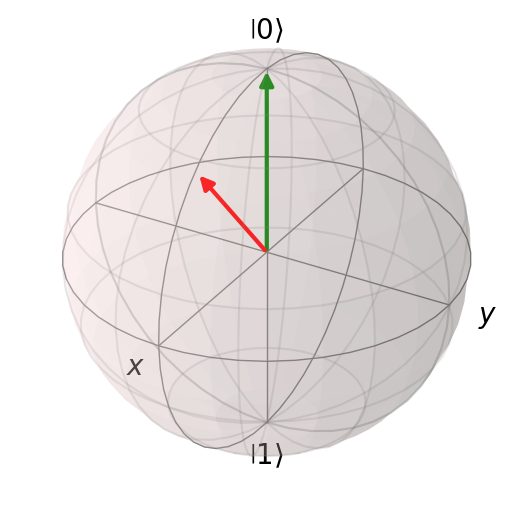

In [96]:
import numpy as np
from qutip import Bloch  


theta = np.pi / 4  
p = 0.9             
n = [0, 1, 0]    

psi = ket0()  
rho_in = np.outer(psi, psi.conj())  

print(psi)
print(rho_in)

R_y  = rotation_gate(theta, n)
print()
print("\n y-axis:\n", R_y)

print()
kraus_y = rotation_channel(p, R_y)
rho_y = apply_kraus(rho_in, kraus_y)


print("\nKraus operators for Y-axis channel:\n", kraus_y)
print()
print("\nDensity matrix after Y channel:\n", rho_y)
print()

v_initial = bloch_vector(rho_in)
v_y = bloch_vector(rho_y)

print("initial Bloch vector:", v_initial)
print("Bloch vector after Y channel:", v_y)

b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_y)        
b.title = "Y-axis Random Rotation Channel Effect on |0>"
b.show()

[ 0.70710678+0.j -0.70710678+0.j]
[[ 0.5+0.j -0.5-0.j]
 [-0.5+0.j  0.5+0.j]]


 y-axis:
 [[ 0.92387953+0.j -0.38268343+0.j]
 [ 0.38268343+0.j  0.92387953+0.j]]


Kraus operators for Y-axis channel:
 [array([[0.31622777+0.j, 0.        +0.j],
       [0.        +0.j, 0.31622777+0.j]]), array([[ 0.87646908+0.j, -0.36304538+0.j],
       [ 0.36304538+0.j,  0.87646908+0.j]])]


Density matrix after Y channel:
 [[ 0.81819805+0.j -0.36819805+0.j]
 [-0.36819805+0.j  0.18180195+0.j]]

initial Bloch vector: [-1.  0.  0.]
Bloch vector after Y channel: [-0.7363961  0.         0.6363961]


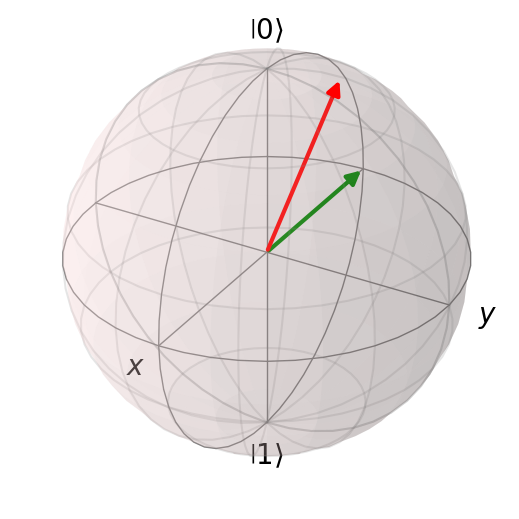

In [97]:

import numpy as np
from qutip import Bloch  


theta = np.pi / 4  
p = 0.9             
n = [0, 1, 0]    

psi = ket_minus()  
rho_in = np.outer(psi, psi.conj())  

print(psi)
print(rho_in)

R_y  = rotation_gate(theta, n)
print()
print("\n y-axis:\n", R_y)

print()
kraus_y = rotation_channel(p, R_y)
rho_y = apply_kraus(rho_in, kraus_y)

print("\nKraus operators for Y-axis channel:\n", kraus_y)
print()
print("\nDensity matrix after Y channel:\n", rho_y)
print()

v_initial = bloch_vector(rho_in)
v_y = bloch_vector(rho_y)

print("initial Bloch vector:", v_initial)
print("Bloch vector after Y channel:", v_y)


b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_y)        
b.title = "Y-axis Random Rotation Channel Effect on |1>"
b.show()

[0.70710678+0.j 0.70710678+0.j]
[[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]


 Y-axis:
 [[ 0.92387953+0.j -0.38268343+0.j]
 [ 0.38268343+0.j  0.92387953+0.j]]


Kraus operators for Y-axis channel:
 [array([[0.31622777+0.j, 0.        +0.j],
       [0.        +0.j, 0.31622777+0.j]]), array([[ 0.87646908+0.j, -0.36304538+0.j],
       [ 0.36304538+0.j,  0.87646908+0.j]])]


Density matrix after Y channel:
 [[0.18180195+0.j 0.36819805+0.j]
 [0.36819805+0.j 0.81819805+0.j]]

initial Bloch vector: [1. 0. 0.]
Bloch vector after Y channel: [ 0.7363961  0.        -0.6363961]


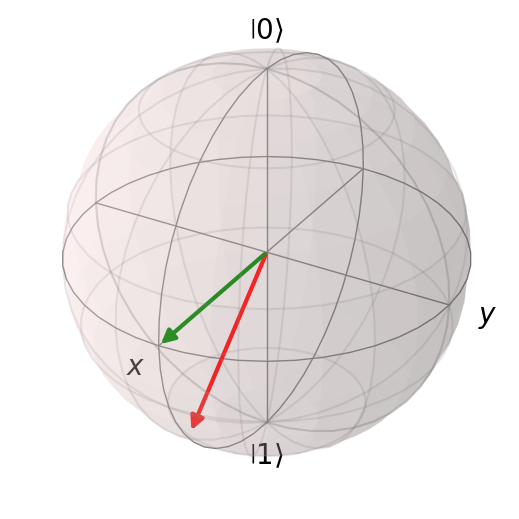

In [98]:

import numpy as np
from qutip import Bloch  

theta = np.pi / 4  
p = 0.9             
n = [0, 1, 0]    

psi = ket_plus() 
rho_in = np.outer(psi, psi.conj())  

print(psi)
print(rho_in)

R_y  = rotation_gate(theta, n)
print()
print("\n Y-axis:\n", R_y)

print()
kraus_y = rotation_channel(p, R_y)
rho_y = apply_kraus(rho_in, kraus_y)


print("\nKraus operators for Y-axis channel:\n", kraus_y)
print()
print("\nDensity matrix after Y channel:\n", rho_y)
print()

v_initial = bloch_vector(rho_in)
v_y = bloch_vector(rho_y)

print("initial Bloch vector:", v_initial)
print("Bloch vector after Y channel:", v_y)

b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_y)        
b.title = "Y-axis Random Rotation Channel Effect on |+>"
b.show()

[1.+0.j 0.+0.j]
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]


 Z-axis:
 [[0.92387953-0.38268343j 0.        +0.j        ]
 [0.        +0.j         0.92387953+0.38268343j]]


Kraus operators for Z-axis channel:
 [array([[0.31622777+0.j, 0.        +0.j],
       [0.        +0.j, 0.31622777+0.j]]), array([[0.87646908-0.36304538j, 0.        +0.j        ],
       [0.        +0.j        , 0.87646908+0.36304538j]])]


Density matrix after Z channel:
 [[1.+2.40545573e-17j 0.+0.00000000e+00j]
 [0.+0.00000000e+00j 0.+0.00000000e+00j]]

initial Bloch vector: [0. 0. 1.]
Bloch vector after Z channel: [0. 0. 1.]


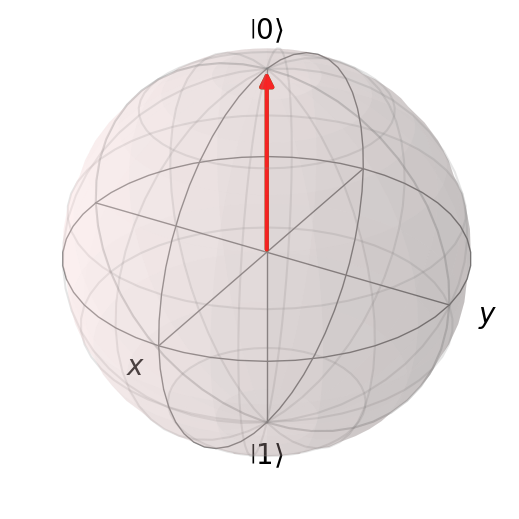

In [99]:

import numpy as np
from qutip import Bloch  


theta = np.pi / 4  
p = 0.9             
n = [0, 0, 1]    


psi = ket0() 
rho_in = np.outer(psi, psi.conj())  

print(psi)
print(rho_in)

R_z  = rotation_gate(theta, n)
print()
print("\n Z-axis:\n", R_z)

print()
kraus_z = rotation_channel(p, R_z)
rho_z = apply_kraus(rho_in, kraus_z)


print("\nKraus operators for Z-axis channel:\n", kraus_z)
print()
print("\nDensity matrix after Z channel:\n", rho_z)
print()

v_initial = bloch_vector(rho_in)
v_z = bloch_vector(rho_z)

print("initial Bloch vector:", v_initial)
print("Bloch vector after Z channel:", v_z)

b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_z)        
b.title = "Z-axis Random Rotation Channel Effect on |0>"
b.show()

[0.+0.j 1.+0.j]
[[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


 y-axis:
 [[0.92387953-0.38268343j 0.        +0.j        ]
 [0.        +0.j         0.92387953+0.38268343j]]


Kraus operators for Z-axis channel:
 [array([[0.31622777+0.j, 0.        +0.j],
       [0.        +0.j, 0.31622777+0.j]]), array([[0.87646908-0.36304538j, 0.        +0.j        ],
       [0.        +0.j        , 0.87646908+0.36304538j]])]


Density matrix after Z channel:
 [[0.+0.00000000e+00j 0.+0.00000000e+00j]
 [0.+0.00000000e+00j 1.-2.40545573e-17j]]

initial Bloch vector: [ 0.  0. -1.]
Bloch vector after Z channel: [ 0.  0. -1.]


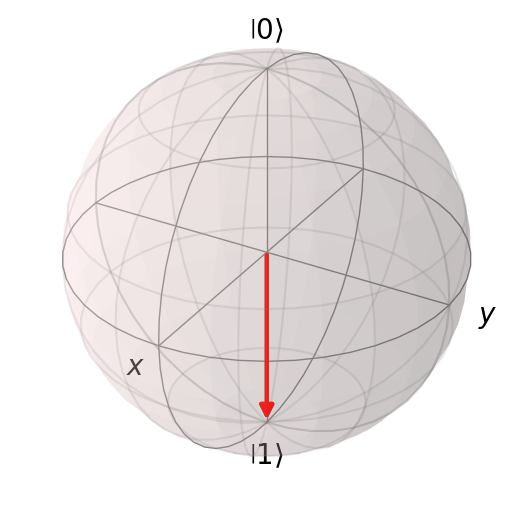

In [100]:

import numpy as np
from qutip import Bloch  


theta = np.pi / 4  
p = 0.9             
n = [0, 0, 1]    


psi = ket1() 
rho_in = np.outer(psi, psi.conj())  

print(psi)
print(rho_in)

R_z  = rotation_gate(theta, n)
print()
print("\n y-axis:\n", R_z)

print()
kraus_z = rotation_channel(p, R_z)
rho_z = apply_kraus(rho_in, kraus_z)

print("\nKraus operators for Z-axis channel:\n", kraus_z)
print()
print("\nDensity matrix after Z channel:\n", rho_z)
print()

v_initial = bloch_vector(rho_in)
v_z = bloch_vector(rho_z)

print("initial Bloch vector:", v_initial)
print("Bloch vector after Z channel:", v_z)

b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_z)        
b.title = "Z-axis Random Rotation Channel Effect on |1>"
b.show()

[0.70710678+0.j 0.70710678+0.j]
[[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]


 y-axis:
 [[0.92387953-0.38268343j 0.        +0.j        ]
 [0.        +0.j         0.92387953+0.38268343j]]


Kraus operators for Z-axis channel:
 [array([[0.31622777+0.j, 0.        +0.j],
       [0.        +0.j, 0.31622777+0.j]]), array([[0.87646908-0.36304538j, 0.        +0.j        ],
       [0.        +0.j        , 0.87646908+0.36304538j]])]


Density matrix after Z channel:
 [[0.5       -2.82788554e-17j 0.36819805-3.18198052e-01j]
 [0.36819805+3.18198052e-01j 0.5       +2.82788554e-17j]]

initial Bloch vector: [1. 0. 0.]
Bloch vector after Z channel: [0.7363961 0.6363961 0.       ]


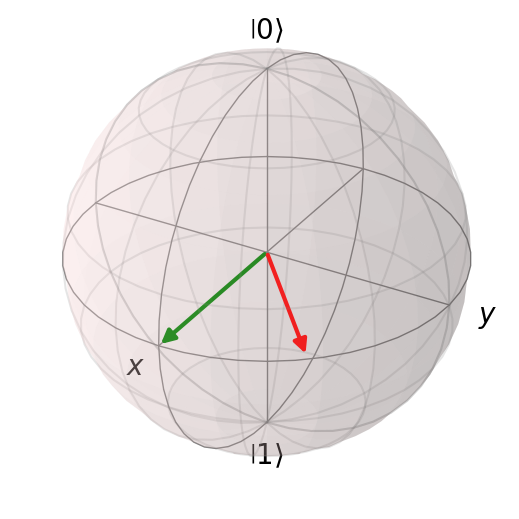

In [101]:

import numpy as np
from qutip import Bloch  

theta = np.pi / 4  
p = 0.9             
n = [0, 0, 1]    

psi = ket_plus() 
rho_in = np.outer(psi, psi.conj())  

print(psi)
print(rho_in)

R_z  = rotation_gate(theta, n)
print()
print("\n y-axis:\n", R_z)

print()
kraus_z = rotation_channel(p, R_z)
rho_z = apply_kraus(rho_in, kraus_z)


print("\nKraus operators for Z-axis channel:\n", kraus_z)
print()
print("\nDensity matrix after Z channel:\n", rho_z)
print()

v_initial = bloch_vector(rho_in)
v_z = bloch_vector(rho_z)

print("initial Bloch vector:", v_initial)
print("Bloch vector after Z channel:", v_z)

b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_z)        
b.title = "Z-axis Random Rotation Channel Effect on |+>"
b.show()

[ 0.70710678+0.j -0.70710678+0.j]
[[ 0.5+0.j -0.5-0.j]
 [-0.5+0.j  0.5+0.j]]


 Z-axis:
 [[0.92387953-0.38268343j 0.        +0.j        ]
 [0.        +0.j         0.92387953+0.38268343j]]


Kraus operators for Z-axis channel:
 [array([[0.31622777+0.j, 0.        +0.j],
       [0.        +0.j, 0.31622777+0.j]]), array([[0.87646908-0.36304538j, 0.        +0.j        ],
       [0.        +0.j        , 0.87646908+0.36304538j]])]


Density matrix after Z channel:
 [[ 0.5       -2.82788554e-17j -0.36819805+3.18198052e-01j]
 [-0.36819805-3.18198052e-01j  0.5       +2.82788554e-17j]]

initial Bloch vector: [-1.  0.  0.]
Bloch vector after Z channel: [-0.7363961 -0.6363961  0.       ]


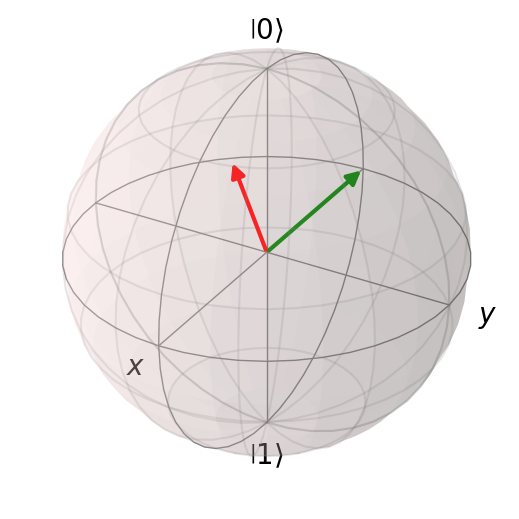

In [102]:

import numpy as np
from qutip import Bloch  

# Parameters
theta = np.pi / 4  
p = 0.9             
n = [0, 0, 1]    

psi = ket_minus() 
rho_in = np.outer(psi, psi.conj())  

print(psi)
print(rho_in)

R_z  = rotation_gate(theta, n)
print()
print("\n Z-axis:\n", R_z)

print()
kraus_z = rotation_channel(p, R_z)
rho_z = apply_kraus(rho_in, kraus_z)


print("\nKraus operators for Z-axis channel:\n", kraus_z)
print()
print("\nDensity matrix after Z channel:\n", rho_z)
print()

v_initial = bloch_vector(rho_in)
v_z = bloch_vector(rho_z)

print("initial Bloch vector:", v_initial)
print("Bloch vector after Z channel:", v_z)

b = Bloch()
b.vector_color = ['green', 'red'] 
b.add_vectors(v_initial)  
b.add_vectors(v_z)        
b.title = "Z-axis Random Rotation Channel Effect on |->"
b.show()

In [41]:
import numpy as np
theta = np.pi/4
n = [1,0,0]
p=0.9
psi = np.array([1,1])/np.sqrt(2)
rho = np.outer(psi.conj(), psi)
R = rotation_gate(theta, n)  
rho_new = rotation_channel(rho, kraus)
print(psi)
print(rho_new)

[0.70710678 0.70710678]
[array([[0.70710678+0.j, 0.        +0.j],
       [0.        +0.j, 0.70710678+0.j]]), array([[[0.31622777+0.j        , 0.        +0.j        ],
        [0.        +0.j        , 0.31622777+0.j        ]],

       [[0.62284711+0.j        , 0.        -0.10982475j],
        [0.        -0.10982475j, 0.62284711+0.j        ]]])]


In [43]:
import numpy as np
p = 0.001
theta = np.pi/4

n = [0,1,0]
psi = np.array([1,1])/np.sqrt(2)
rho = np.outer(psi.conj(), psi)
R = rotation_gate(theta, n)  
rho_new = rotation_channel(rho, kraus)
print(psi)
print(rho_new)

[0.70710678 0.70710678]
[array([[0.70710678+0.j, 0.        +0.j],
       [0.        +0.j, 0.70710678+0.j]]), array([[[0.31622777+0.j        , 0.        +0.j        ],
        [0.        +0.j        , 0.31622777+0.j        ]],

       [[0.62284711+0.j        , 0.        -0.10982475j],
        [0.        -0.10982475j, 0.62284711+0.j        ]]])]


In [44]:
import numpy as np
p = 0.3
theta = np.pi/4

Rx = rotation_gate(theta, [1,0,0])
kraus_x = rotation_channel(p, Rx)

rho_x = rotation_channel(rho, kraus_x)
print("X channel:")
print(rho_x)

X channel:
[array([[0.70710678+0.j, 0.        +0.j],
       [0.        +0.j, 0.70710678+0.j]]), array([[[0.59160798+0.j        , 0.        +0.j        ],
        [0.        +0.j        , 0.59160798+0.j        ]],

       [[0.357817  +0.j        , 0.        -0.14821266j],
        [0.        -0.14821266j, 0.357817  +0.j        ]]])]


#### (b) Visualization on the Bloch sphere

Write a function that calculates the Bloch vector $\overrightarrow{r}=(r_X,r_Y,r_Z)$ (called $P$ in the lecture) for a given single qubit density matrix. On Problem Set 2, we calculated the Bloch vector for a pure state (so that formalism won't necessarily work here). For mixed states, one can calculate the Bloch vector element via the equation 
$$r_J = \mathrm{Tr}(\rho J),$$ 
where $J$ is either $X,Y,Z$ and $\mathrm{Tr}$ represents the trace of a matrix (see `np.trace`).

First, take a pure state (say, for example, $|\psi\rangle = |1\rangle$). Apply (separately) each of the three channels we defined earlier to this state. Plot the original state on the Bloch sphere, as well as the three states after applying the channels (i.e., one state with the phase flip, the other with the bit flip, the other with the amplitude damping). Play around with the parameters to see how the channels alter the state.

Second, sample some homogeneously distributed points on the surface of the Bloch sphere by generating random pure states. An easy way to do this is to sample 2-dimensional vectors of complex numbers with random Gaussian distributed real and imaginary parts. Don't forget to normalise your state after generating the random values!

Tip for random state generation: generate the real and complex part of state separately. You may find the function `np.random.normal(mu,sigma,dim)` to be useful here.

Apply the channels defined above (e.g., with $p=0.3$) to each of these random pure states. Calculate the resulting Bloch vectors and plot them (with the original Bloch vectors) on the Bloch sphere to see the "flow" in the Bloch sphere that each channel induces.

Quantum Noise Channels on the Bloch Sphere
Green vectors = original states
Red vectors = states after the noise channel
States used: |0> and |+>



Bit Flip on |0>:
 [[0.7+0.j 0. +0.j]
 [0. +0.j 0.3+0.j]]
Bit Flip on |+>:
 [[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]

Phase Flip on |0>:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]
Phase Flip on |+>:
 [[0.5+0.j 0.2+0.j]
 [0.2+0.j 0.5+0.j]]

Amplitude Damping on |0>:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]
Amplitude Damping on |+>:
 [[0.65      +0.j 0.41833001+0.j]
 [0.41833001+0.j 0.35      +0.j]]

Bit Flip Bloch vector|0>: [0.  0.  0.4]
Bit Flip Bloch vector|+>: [1. 0. 0.]
Phase Flip Bloch vector|0>: [0. 0. 1.]
Phase Flip Bloch vector|+>: [0.4 0.  0. ]
Amplitude Damping Bloch vector|0>: [0. 0. 1.]
Amplitude Damping Bloch vector|+>: [0.83666003 0.         0.3       ]

Bloch Sphere: Bit Flip Channel


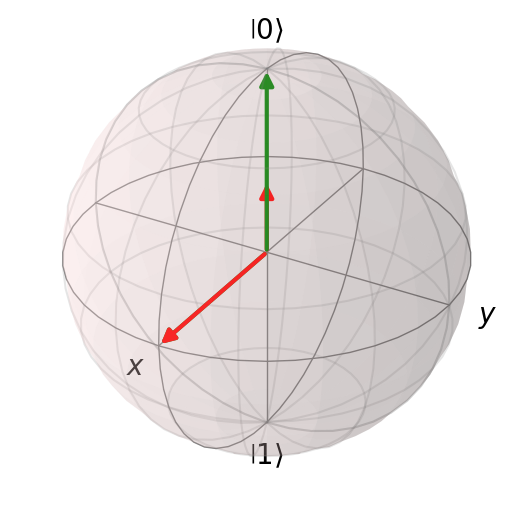


Bloch Sphere: Phase Flip Channel


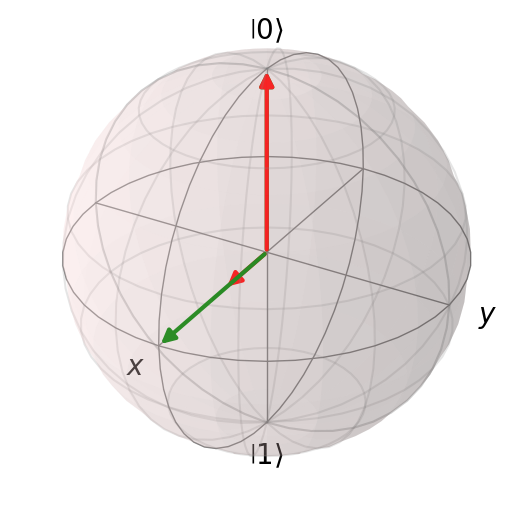


Bloch Sphere: Amplitude Damping Channel


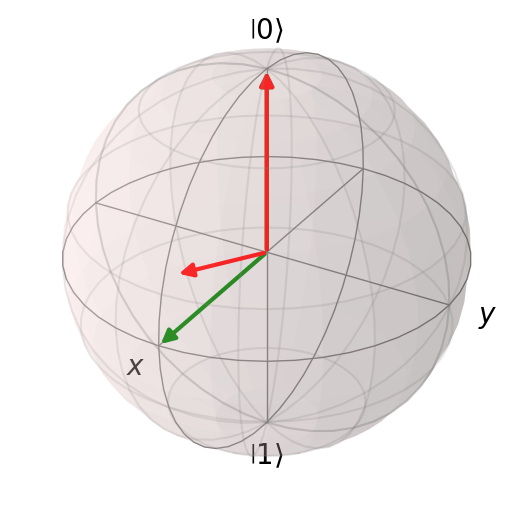

In [12]:
from qutip import Bloch

print("Quantum Noise Channels on the Bloch Sphere")
print("Green vectors = original states")
print("Red vectors = states after the noise channel")
print("States used: |0> and |+>")
print()

# Set channel probability
p = 0.3

bitflip_ops = bit_flip_kraus(p)
phaseflip_ops = phase_flip_kraus(p)
ampdamp_ops = amplitude_damping_kraus(p)

# Define states
psi0 = ket0()
psi_plus = ket_plus()

# Convert to density matrices
rho0 = dm(psi0)
rho_plus = dm(psi_plus)

# Apply channels
rho0_bitflip = apply_channel(rho0, bitflip_ops)
rho_plus_bitflip = apply_channel(rho_plus, bitflip_ops)

rho0_phaseflip = apply_channel(rho0, phaseflip_ops)
rho_plus_phaseflip = apply_channel(rho_plus, phaseflip_ops)

rho0_ampdamp = apply_channel(rho0, ampdamp_ops)
rho_plus_ampdamp = apply_channel(rho_plus, ampdamp_ops)

# Print density matrices
print()
print("\nBit Flip on |0>:\n", rho0_bitflip)
print("Bit Flip on |+>:\n", rho_plus_bitflip)

print("\nPhase Flip on |0>:\n", rho0_phaseflip)
print("Phase Flip on |+>:\n", rho_plus_phaseflip)

print("\nAmplitude Damping on |0>:\n", rho0_ampdamp)
print("Amplitude Damping on |+>:\n", rho_plus_ampdamp)

print()
print("Bit Flip Bloch vector|0>:", bloch_vector(rho0_bitflip))
print("Bit Flip Bloch vector|+>:", bloch_vector(rho_plus_bitflip))

print("Phase Flip Bloch vector|0>:", bloch_vector(rho0_phaseflip))
print("Phase Flip Bloch vector|+>:", bloch_vector(rho_plus_phaseflip))

print("Amplitude Damping Bloch vector|0>:", bloch_vector(rho0_ampdamp))
print("Amplitude Damping Bloch vector|+>:", bloch_vector(rho_plus_ampdamp))


print("\nBloch Sphere: Bit Flip Channel")
b1 = Bloch()
b1.vector_color = ['green','green','red','red']

b1.add_vectors(bloch_vector(rho0))
b1.add_vectors(bloch_vector(rho_plus))

b1.add_vectors(bloch_vector(rho0_bitflip))
b1.add_vectors(bloch_vector(rho_plus_bitflip))

b1.title = "Bit flip channel effect"
b1.show()


print("\nBloch Sphere: Phase Flip Channel")
b2 = Bloch()
b2.vector_color = ['green','green','red','red']

b2.add_vectors(bloch_vector(rho0))
b2.add_vectors(bloch_vector(rho_plus))

b2.add_vectors(bloch_vector(rho0_phaseflip))
b2.add_vectors(bloch_vector(rho_plus_phaseflip))

b2.title = "Phase flip channel effect"
b2.show()


print("\nBloch Sphere: Amplitude Damping Channel")
b3 = Bloch()
b3.vector_color = ['green','green','red','red']

b3.add_vectors(bloch_vector(rho0))
b3.add_vectors(bloch_vector(rho_plus))

b3.add_vectors(bloch_vector(rho0_ampdamp))
b3.add_vectors(bloch_vector(rho_plus_ampdamp))

b3.title = "Amplitude Damping Channel Effect"
b3.show()

### Bloch Sphere Visualization of Quantum Noise Channels

We study how Bit Flip, Phase Flip, and Amplitude Damping channels affect the qubit states |0⟩ and |+⟩. Green arrows represent the original states, and red arrows represent the states after the noise channel.

### Problem 2: Channels on a register

Similar to Q3 on Problem Set 2, we will now consider single qubit channels which act on qubits that are part of a register. 

#### (a) Single qubit channels in an n-bit register

Build Kraus operators for a given channel that act on qubit $i$ within a register of $n$ qubits. The unitary single qubit gates considered on Problem Set 2 are a subclass of these.

Use Kronecker products and sparse matrices as we did on Problem Set 2.

Hints: Recall that that if we want to apply a single qubit gate in this formalism, we can do so in the same way we apply the Kraus operators, e.g., if we want to apply a Hadamard gate, the channel would be 
$$\mathcal{E}(\rho) = H\rho H^\dagger.$$

Build your single quubit channel acting on the n-qubit register by creating a list of single qubit gates acting on the n-qubit register. That is, create the single qubit Kraus operators acting on the n-qubit register, then use these to create the channel.

Test your function on a few states where we already know the result, e.g., apply the Hadamard *channel* to the $|0\rangle$ state. 

#### (b) Noisy Bell state preparation

Now apply this formalism to simulate a noisy Bell state preparation (i.e., two qubits). After applying the Hadamard and CNOT gates to the register (to create the Bell state), apply bit flip channels to both qubits.

After this, calculate the fidelity with the perfect Bell state. The fidelity of the state is given by $$F=\sqrt{|\langle\psi|\rho|\psi\rangle|},$$
where $|\psi\rangle$ is the (pure) target state (in our case, the perfect Bell state).

Plot the fidelity as a function of $p$ to observe how the noisy Bell state preparation changes for varying the probability of having a bit flip.

Hints: 
1) Write a function that takes $p$ as an input and returns the fidelity.

2) Prepare your perfect Bell state using unitary gates.

In [13]:
# helper functions that we used in the last coding assignment

def buildSparseGateSingle(n, i, gate):
    sgate = sparse.csr_matrix(gate)
    return sparse.kron(sparse.kron(sparse.identity(2**i), sgate), sparse.identity(2**(n-i-1)))

def buildSparseCNOT(n, ic, it):
    P0ic = buildSparseGateSingle(n, ic, P0)
    P1ic = buildSparseGateSingle(n, ic, P1)
    Xit  = buildSparseGateSingle(n, it, X)
    return P0ic + P1ic @ Xit

In [14]:
# helper function for initializing all qubits in state zero
def initRegisterPsi(n):
    return basisvec(n,0)

def initRegisterRho(n):
    ini = basisvec(n,0)
    return np.outer(ini.conj(),ini)

### Problem 3: Simulating a quantum error correction protocol

We now come to the part of the assignment where we will implement an error correction code to the noisy state preparation. We assume perfect circuit elements and only apply error channels at certain points.

We will focus on the 3-qubit bit flip code.

#### (a) Error correction protocol

Simulate each step of the error correction protocol. In each step you should test that your code produces the expected outcome.

1) Encoding: Write a function that takes as an input a general single-qubit state. The output is the encoded state for the three qubit code space of the bit flip code and calculated by simulating the encoding circuit (the second and third qubit are initialized in state $|0\rangle$). You may assume that the input state is pure. 

2) Error: Write a function that applies the bit flip channel to all (three) qubits of the register.

3) Syndrome measurement: In order to perform the syndrome measurement you have to build the projectors $(P_0,P_1,P_2,P_3)$ onto the subspaces corresponding to different error syndromes, i.e., possible outcomes of the syndrome measurement. With these you can simulate the syndrome measurement using the function `doMeasurement()` provided below. Make sure you understand what it does.

4) Recovery: Apply the recovery operation corresponding to the detected syndrome, i.e., apply the channel $\mathcal{E}(\rho)=M_i \rho M_i^\dagger$ with $M_i = 1,X_1,X_2,X_3$, respectively, for the bit flip channel.

Optional: Do all of this for the phase flip code also!

The error correction protocol is not always successful, namely in the case where two or three errors occur. How does this manifest in the simulated protocol? Try different input states and different noise strengths.


1) Encoding: Write a function that takes as an input a general single-qubit state. The output is the encoded state for the three qubit code space of the bit flip code and calculated by simulating the encoding circuit (the second and third qubit are initialized in state $|0\rangle$). You may assume that the input state is pure. 

In [32]:
# Example usage
psi = np.array([0.5, 0.5])  
encoded_psi = encode_3_qubit_bit_flip_code(psi)

print("Encoded 3-qubit state:")
print(encoded_psi)

Encoded 3-qubit state:
[0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]


2. Error: Write a function that applies the bit flip channel to all (three) qubits of the register.

In [ ]:
psi = np.array([[0.5], [0.5]])
psi = np.kron(psi, np.kron(ket0(), ket0()))
print(psi)

In [ ]:
import numpy as np

psi = np.array([[0.5], [0.5]])

print(psi)
encoded = encode_3_qubit_bit_flip_code(psi)
print("Encoded state:\n", encoded)
psi_after_noise = bit_flip_channel_3qubits(encoded, p)
print("State after noise:\n", psi_after_noise)

error = np.kron(I, np.kron(X, I))
errored_state = error @ encoded
print("Errored state:\n", errored_state)

syndrome = syndrome_measurement(errored_state)
print("Syndrome (S1, S2):", syndrome)

corrected_state = correct_bit_flip(errored_state)
print("Corrected state:\n", corrected_state)

In [ ]:
import numpy as np

psi = np.array([[0.3], [0.7]])

encoded = encode_3_qubit_bit_flip_code(psi)
print("Encoded state:")
print(encoded)

error = np.kron(I, np.kron(I, X))  
errored_state = error @ encoded
print("errored_state")
print(errored_state)

syndrome = syndrome_measurement(errored_state)
print("Syndrome (S1, S2):", syndrome)

corrected_state = correct_bit_flip(errored_state)
print("Corrected state:")
print(corrected_state)

3) Syndrome measurement: In order to perform the syndrome measurement you have to build the projectors $(P_0,P_1,P_2,P_3)$ onto the subspaces corresponding to different error syndromes, i.e., possible outcomes of the syndrome measurement. With these you can simulate the syndrome measurement using the function `doMeasurement()` provided below. Make sure you understand what it does.

In [ ]:
import numpy as np

def basis_state(i, n=8):
    v = np.zeros((n,1), dtype=complex)
    v[i,0] = 1
    return v

def projector(v):
    return v @ v.conj().T

b = [basis_state(i) for i in range(8)]

# syndrome projectors
P0 = projector(b[0]) + projector(b[7])   # |000>, |111|
P1 = projector(b[4]) + projector(b[3])   # |100>, |011|
P2 = projector(b[2]) + projector(b[5])   # |010>, |101|
P3 = projector(b[1]) + projector(b[6])   # |001>, |110|

print(P0)
print()
print(P1)
print()
print(P2)
print()
print(P3)

4) Recovery: Apply the recovery operation corresponding to the detected syndrome, i.e., apply the channel $\mathcal{E}(\rho)=M_i \rho M_i^\dagger$ with $M_i = 1,X_1,X_2,X_3$, respectively, for the bit flip channel.

Optional: Do all of this for the phase flip code also!

The error correction protocol is not always successful, namely in the case where two or three errors occur. How does this manifest in the simulated protocol? Try different input states and different noise strengths.

In [ ]:
# helper function for simulating measurements

def doMeasurement(rho, projectors): # inputs: state rho, list of projectors on the subspaces corresponding to different measurement outcomes
    pvec = [np.trace(rho @ pi) for pi in projectors]                      # calculate the probability of each outcome
    thresholds = np.cumsum(pvec)                                          # calculate thresholds for outcomes
    r = np.random.rand()                                                  # generate random number between 0 and 1
    indOutcome = np.sum(thresholds < r)                                   # randomly choose an outcome
    postMeasState = projectors[indOutcome] @ rho @ projectors[indOutcome] # unnormalized post-measurement state
    return [indOutcome , postMeasState/pvec[indOutcome]] # outputs: outcome of the measurement and post-measurement state

I8 = np.eye(8, dtype=complex)

X1 = np.kron(X, np.kron(I, I))
X2 = np.kron(I, np.kron(X, I))
X3 = np.kron(I, np.kron(I, X))

def recovery_bit_flip(rho, syndrome):
    """
    Apply recovery operation depending on syndrome outcome
    """
    recovery_ops = [I8, X1, X2, X3]
    M = recovery_ops[syndrome]
    return M @ rho @ M.conj().T

Z1 = np.kron(Z, np.kron(I, I))
Z2 = np.kron(I, np.kron(Z, I))
Z3 = np.kron(I, np.kron(I, Z))

def recovery_phase_flip(rho, syndrome):
    """
    Apply recovery for phase-flip code
    """
    recovery_ops = [I8, Z1, Z2, Z3]
    M = recovery_ops[syndrome]
    return M @ rho @ M.conj().T

#### (b) Analyzing the performance of the error correction protocol

Use the state obtained by applying the error channel to study the average performance (success rate) of the error correction propotcol and compare it to the case where no error correction is applied: Write a loop that perform the error correction protocol (syndrome measurement and recovery) multiple times. Each time the simulation of the measurement will provide random outcomes.

Calculate the average fidelity over many runs, i.e., the fidelity between the errror corrected state and the encoded state before the error channel.

Compare this to the non-corrected fidelity, i.e., the fidelity between the initial single qubit input state and the state after applying the error channel to this qubit.

How much does the error correction protocol improve the fidelity? How does this depend on the error probability $p$? It will also depend on the input state! Recall that there are states that are not affected at all by the bit flip channel. Can the error corrected fidelity be worse than the uncorrected one?


X-channel on |0>:
Bloch vector before: [0. 0. 1.]
Bloch vector after:  [ 0.         -0.67175144  0.72175144]


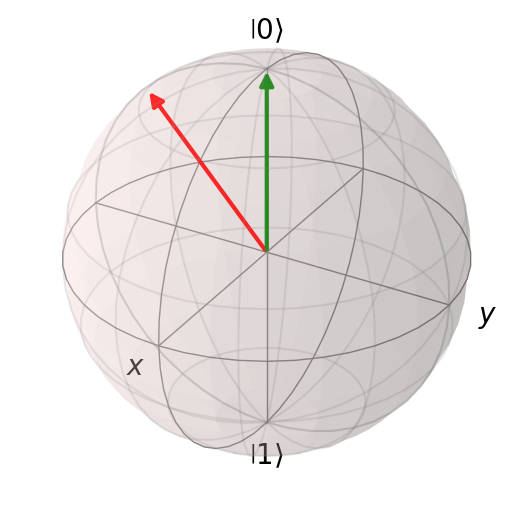


X-channel on |1>:
Bloch vector before: [ 0.  0. -1.]
Bloch vector after:  [ 0.          0.67175144 -0.72175144]


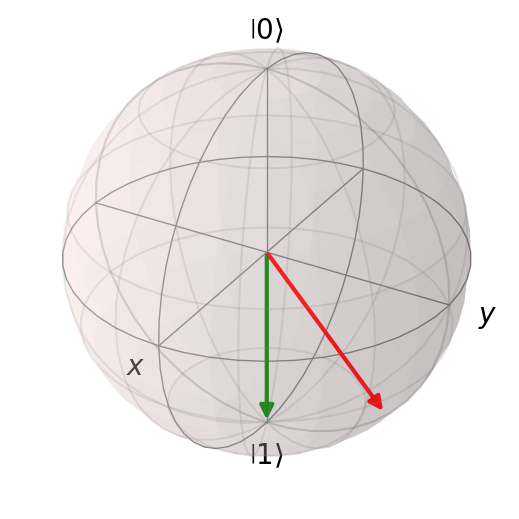


X-channel on |+>:
Bloch vector before: [1. 0. 0.]
Bloch vector after:  [1.00000000e+00 1.60649850e-17 5.55111512e-17]


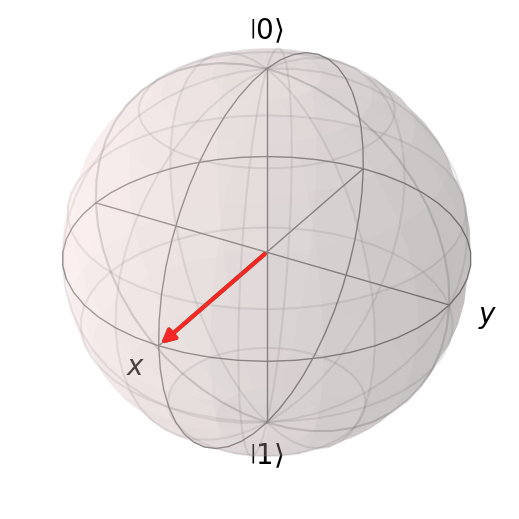


X-channel on |->:
Bloch vector before: [-1.  0.  0.]
Bloch vector after:  [-1.00000000e+00  1.60649850e-17  5.55111512e-17]


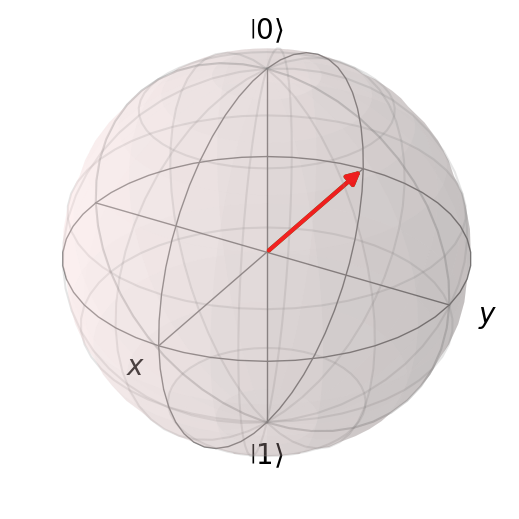


Y-channel on |0>:
Bloch vector before: [0. 0. 1.]
Bloch vector after:  [0.67175144 0.         0.72175144]


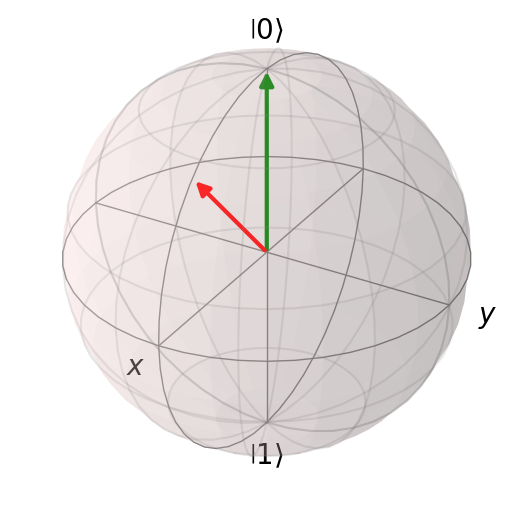


Y-channel on |1>:
Bloch vector before: [ 0.  0. -1.]
Bloch vector after:  [-0.67175144  0.         -0.72175144]


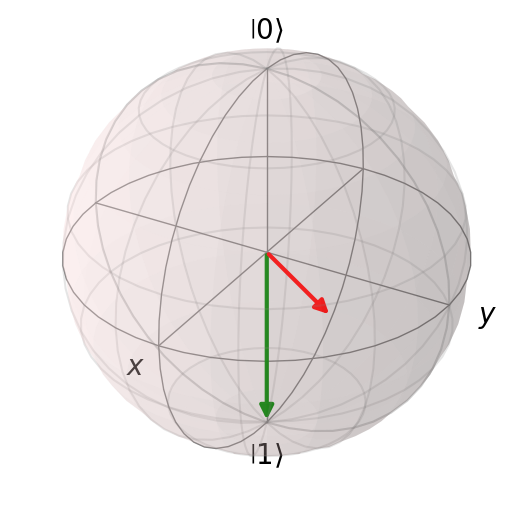


Y-channel on |+>:
Bloch vector before: [1. 0. 0.]
Bloch vector after:  [ 0.72175144  0.         -0.67175144]


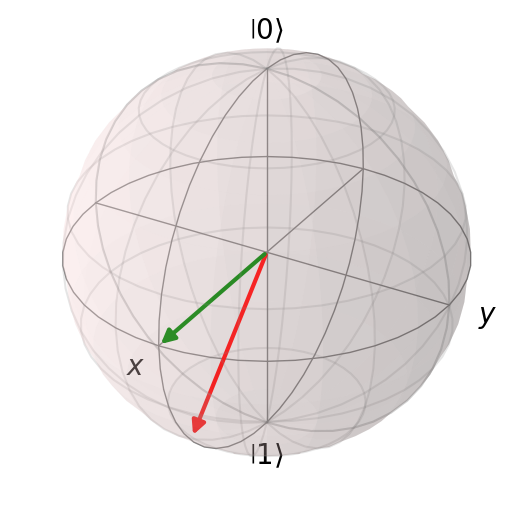


Y-channel on |->:
Bloch vector before: [-1.  0.  0.]
Bloch vector after:  [-0.72175144  0.          0.67175144]


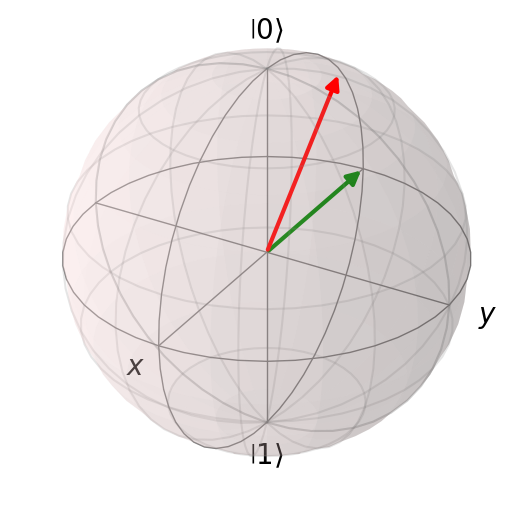


Z-channel on |0>:
Bloch vector before: [0. 0. 1.]
Bloch vector after:  [0. 0. 1.]


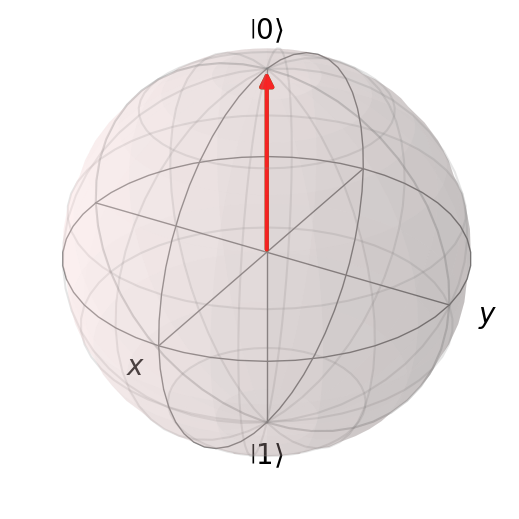


Z-channel on |1>:
Bloch vector before: [ 0.  0. -1.]
Bloch vector after:  [ 0.  0. -1.]


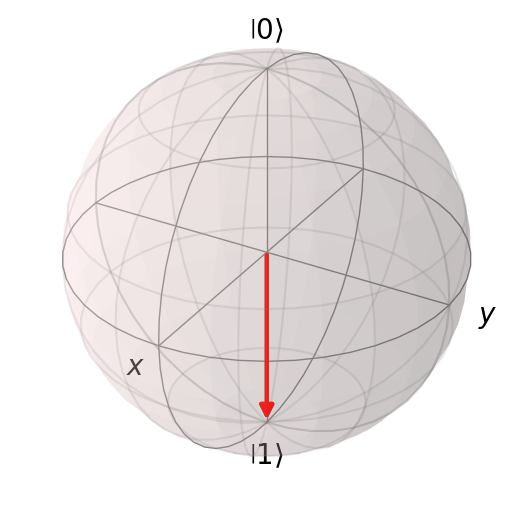


Z-channel on |+>:
Bloch vector before: [1. 0. 0.]
Bloch vector after:  [0.72175144 0.67175144 0.        ]


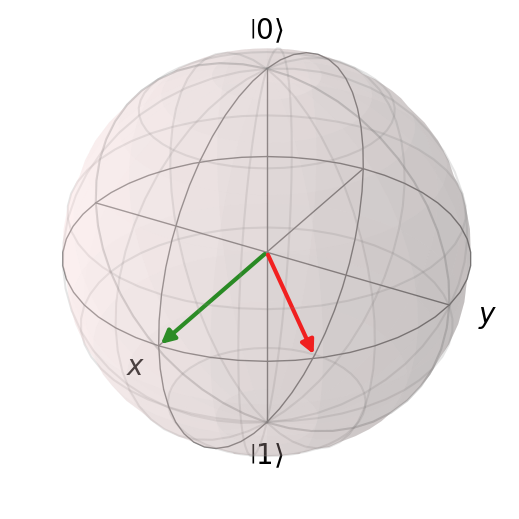


Z-channel on |->:
Bloch vector before: [-1.  0.  0.]
Bloch vector after:  [-0.72175144 -0.67175144  0.        ]


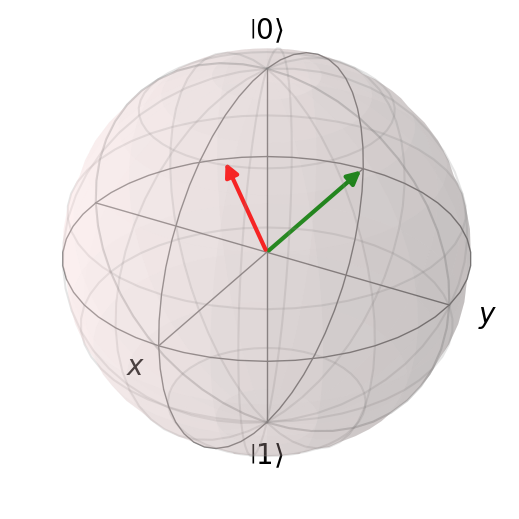

In [19]:
import numpy as np
from qutip import Bloch

# Channel parameters
p = 0.95
theta = np.pi/4

# Initial states
states = {
    '|0>': ket0(),
    '|1>': ket1(),
    '|+>': ket_plus(),
    '|->': ket_minus()
}

# Rotation axes
channels = {
    'X': [1,0,0],
    'Y': [0,1,0],
    'Z': [0,0,1]
}


# Loop over channels and states
for ch_name, axis in channels.items():
    R = rotation_gate(theta, axis)
    kraus = rotation_channel(p, R)
    
    for state_name, psi in states.items():
        
        # Density matrix
        rho_in = np.outer(psi, psi.conj())
        rho_out = apply_kraus(rho_in, kraus)

         
        print(f"\n{ch_name}-channel on {state_name}:")
        print("Bloch vector before:", bloch_vector(rho_in))
        print("Bloch vector after: ", bloch_vector(rho_out))
        
        
        # Bloch sphere visualization
        
        b = Bloch()
        b.vector_color = ['green', 'red']
        b.add_vectors(bloch_vector(rho_in))  # initial
        b.add_vectors(bloch_vector(rho_out)) # after channel
        b.title = f"{state_name} under {ch_name}-axis rotation channel"
        b.show()